In [2]:
# single-cell analysis package
library(Seurat)

# plotting and data science packages
library(repr)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

# co-expression network analysis packages:
library(WGCNA)
library(hdWGCNA)

source("./Modified_functions.R")

# enable parallel processing for network analysis (optional)
enableWGCNAThreads(nThreads = 8)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Allowing parallel execution with up to 8 working processes.


In [3]:
# Output Directory
outDir <- file.path("./results")

# load the unprocessed dataset
wgcna_obj <- readRDS(file.path('./results/ST_tumor_hdWGCNA_object.rds'))
print(wgcna_obj)
length(GetWGCNAGenes(wgcna_obj))

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8


[1] 11729

In [4]:
#  harmonized module eigengenes (hMEs)
hMEs <- GetMEs(wgcna_obj)
print(dim(hMEs))

# add the MEs to the seurat metadata so we can plot it with Seurat functions
wgcna_obj@meta.data <- cbind(wgcna_obj@meta.data, hMEs)
dim(wgcna_obj@meta.data)

[1] 11472     8


[1] 11472    23

In [5]:
# get hub genes
hub_df <- GetHubGenes(wgcna_obj, n_hubs = 50)
print(dim(hub_df))
head(hub_df, 4)

[1] 350   3


,gene_name,module,kME
,<chr>,<fct>,<dbl>
1,HLA-B,Tumor-M1,0.6547283
2,IGLC2,Tumor-M1,0.6216158
3,IGHG1,Tumor-M1,0.6092280
4,IGKC,Tumor-M1,0.6031249


## Enrichment Analysis

In [7]:
# gene enrichment packages
library(enrichR)
library(GeneOverlap)

In [8]:
print(length(GetWGCNAGenes(wgcna_obj)))
wgcna_genes = data.frame(GetWGCNAGenes(wgcna_obj))
colnames(wgcna_genes) <- c("wgcna_Genes")
#write.csv(wgcna_genes, "./results/wgcna_Genes.csv", row.names = FALSE)

[1] 11729


In [9]:
RunEnrichr <- function (seurat_obj, dbs = c("GO_Biological_Process_2021", "GO_Cellular_Component_2021", 
    "GO_Molecular_Function_2021"), max_genes = 100, wait = TRUE, 
    wait_time = 5, wgcna_name = NULL, ...) 
{
    if (is.null(wgcna_name)) {
        wgcna_name <- seurat_obj@misc$active_wgcna
    }
    CheckWGCNAName(seurat_obj, wgcna_name)
    if (!is.numeric(wait_time)) {
        stop(paste0("wait_time must be a numeric."))
    }
    if (wait_time > 60 | wait_time < 1) {
        stop(paste0("Invalid value selected for wait_time, must be greater than 0 and less than 60."))
    }
    modules <- GetModules(seurat_obj, wgcna_name)
    mods <- levels(modules$module)
    mods <- mods[mods != "grey"]
    hub_df <- GetHubGenes(seurat_obj, n_hubs = max_genes, wgcna_name = wgcna_name)
    combined_output <- data.frame()
    for (i in 1:length(mods)) {
        cur_mod <- mods[i]
        cur_info <- subset(hub_df, module == cur_mod)
        cur_genes <- as.character(cur_info$gene_name)
        print(length(cur_genes))
        enriched <- enrichR::enrichr(cur_genes, dbs, background = GetWGCNAGenes(wgcna_obj))
        if (wait) {
            Sys.sleep(wait_time)
        }
        for (db in names(enriched)) {
            cur_df <- enriched[[db]]
            if (nrow(cur_df) > 1) {
                cur_df$db <- db
                cur_df$module <- cur_mod
                combined_output <- rbind(combined_output, cur_df)
            }
        }
    }
    seurat_obj <- SetEnrichrTable(seurat_obj, combined_output, 
        wgcna_name)
    seurat_obj
}


In [10]:
# define the enrichr databases to test
dbs <- c('MSigDB_Hallmark_2020')

# perform enrichment tests
wgcna_obj <- RunEnrichr(
  wgcna_obj,
  dbs=dbs,
  max_genes = Inf # use max_genes = Inf to choose all genes
)

# retrieve the output table
msigdb_enrich_df <- GetEnrichrTable(wgcna_obj)

# look at the results
head(msigdb_enrich_df)

[1] 658
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - MSigDB_Hallmark_2020... Done.
Parsing results... Done.
[1] 2040
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - MSigDB_Hallmark_2020... Done.
Parsing results... Done.
[1] 79
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - MSigDB_Hallmark_2020... Done.
Parsing results... Done.
[1] 711
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - MSigDB_Hallmark_2020... Done.
Parsing results... Done.
[1] 583
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - MSigDB_Hallmark_2020... Done.
Parsing results... Done.
[1] 90
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Don

,Term,Rank,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes,db,module
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,Epithelial Mesenchymal Transition,1,4.655412e-36,2.281152e-34,0,0,10.736211,873.4448,ECM1;SPARC;COL16A1;ITGB5;WIPF1;COL12A1;TNC;PLOD1;LAMC1;LOXL2;GJA1;GLIPR1;BASP1;ANPEP;ITGAV;EDIL3;COLGALT1;PDGFRB;POSTN;IGFBP4;MMP2;APLP1;P3H1;PCOLCE;EMP3;DCN;MMP14;VCAN;COL4A2;LOX;COL6A2;ADAM12;CDH11;GAS1;COL6A3;ITGA5;LRP1;COL11A1;HTRA1;FBLN1;THBS2;FSTL1;SERPINH1;CTHRC1;IL32;VCAM1;TGFB1;PRRX1;LUM;FN1;COL1A1;COL3A1;DAB2;COL1A2;BMP1;CXCL12;FAP;COL5A1;COL5A3;COL5A2;PMP22;SNAI2;TGFBI;FBN1,MSigDB_Hallmark_2020,Tumor-M1
2,Allograft Rejection,2,1.798574e-18,4.406506e-17,0,0,8.373244,342.1269,CXCL9;SPI1;ITGAL;IL2RG;ETS1;CTSS;ICAM1;HLA-DMB;CCL5;STAB1;CCL4;HLA-DOA;GBP2;B2M;HLA-DQA1;MAP4K1;SRGN;FYB1;TGFB1;F2R;TAP2;TAP1;IL16;HLA-A;MMP9;HLA-E;CD4;PTPRC;CD8A;IRF7;HLA-DRA;IRF8;LCP2;LTB;FCGR2B;EIF3D,MSigDB_Hallmark_2020,Tumor-M1
3,Interferon Gamma Response,3,1.336989e-15,2.183748e-14,0,0,5.667832,194.1139,SAMD9L;CXCL9;CIITA;C1S;C1R;FGL2;NLRC5;SECTM1;UBE2L6;IFI35;ICAM1;APOL6;CCL5;CASP1;SLAMF7;FCGR1A;B2M;HLA-DQA1;GBP4;IL15RA;VCAM1;STAT2;IL10RA;HLA-B;TAP1;HLA-A;PARP14;BST2;ISG20;CXCL10;IRF1;IRF7;PSME2;IRF8;LCP2;LAP3;XAF1;VAMP5;HLA-DRB1;IDO1,MSigDB_Hallmark_2020,Tumor-M1
4,Complement,4,6.678811e-12,8.181544e-11,0,0,5.140897,132.2860,C1QA;ITGAM;C1S;LRP1;C1R;PLEK;LIPA;PLA2G7;CTSS;CTSL;CCL5;TIMP2;CASP1;CTSH;CTSD;CTSB;FCER1G;APOBEC3G;HSPA5;ANXA5;FN1;RHOG;MMP14;COL4A2;IRF1;APOC1;GNB4;IRF7;CALM3;LCP2;LAP3;C1QC,MSigDB_Hallmark_2020,Tumor-M1
5,Inflammatory Response,5,1.331902e-09,1.305264e-08,0,0,5.104544,104.3198,CXCL9;LPAR1;ICAM1;CCL5;STAB1;PDPN;C3AR1;CD14;ABCA1;IL15RA;MSR1;IL10RA;RHOG;CYBB;EMP3;TNFRSF1B;BST2;CXCL10;MMP14;AXL;IRF1;IRF7;CD48;LCP2;ITGA5,MSigDB_Hallmark_2020,Tumor-M1
6,Coagulation,6,3.812790e-09,3.113778e-08,0,0,5.515541,106.9182,CFD;C1QA;SPARC;GSN;C1S;LRP1;C1R;MMP2;PLEK;HTRA1;FN1;PRSS23;MMP9;MMP11;MMP14;BMP1;CTSK;APOC1;PECAM1;CTSH;FBN1;CTSB,MSigDB_Hallmark_2020,Tumor-M1


In [11]:
print(dim(msigdb_enrich_df))
filtered_msigdb_enrich_df = filter(msigdb_enrich_df, Adjusted.P.value< 0.05)
print(dim(filtered_msigdb_enrich_df))
#write.csv(filtered_msigdb_enrich_df, "./results/msigdb_enrichr_table.csv", row.names = FALSE)

[1] 271  11
[1] 44 11


Warning message:
“The `size` argument of `element_rect()` is deprecated as of
ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of
ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


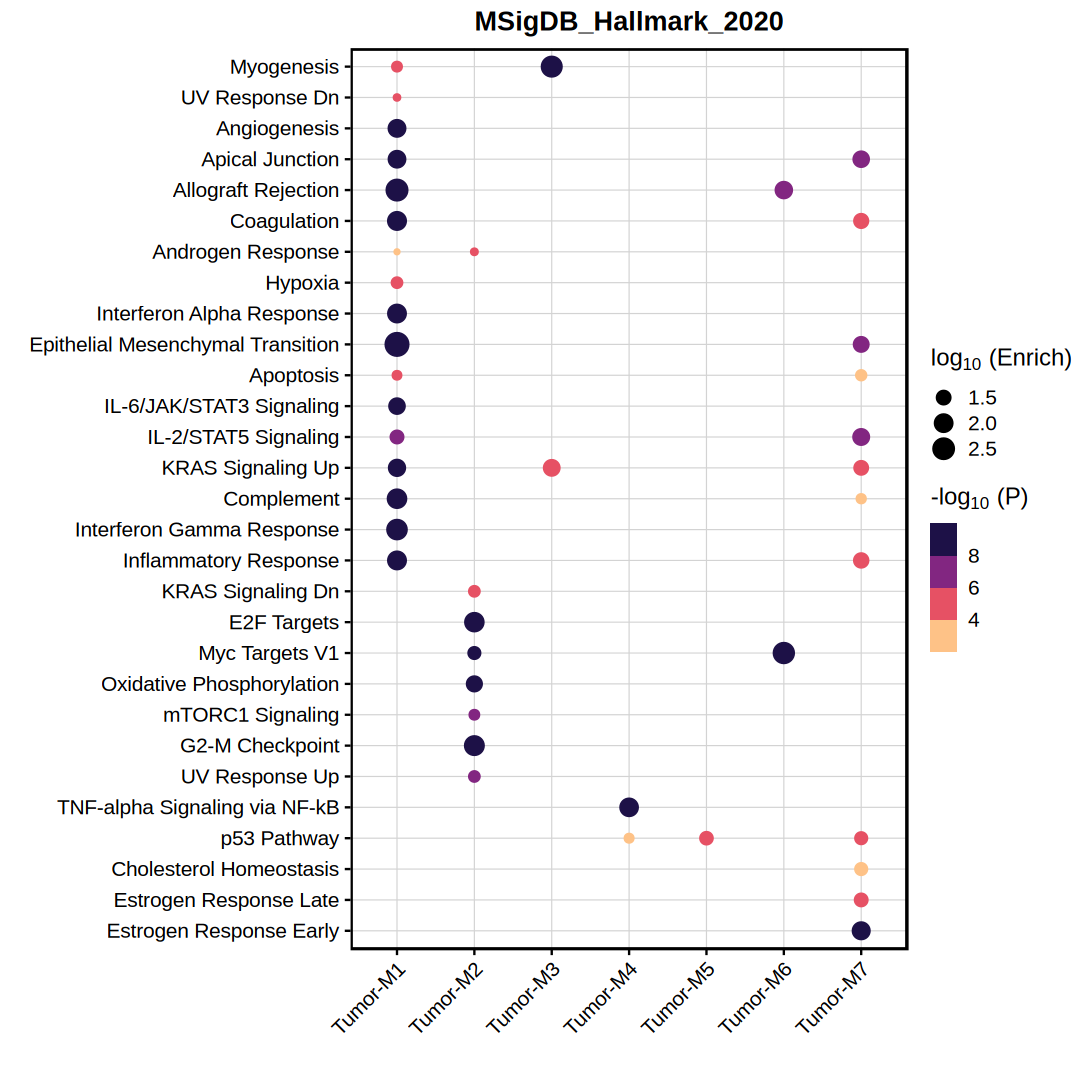

In [12]:
options(repr.plot.height = 9, repr.plot.width = 9)
#png(filename = "./results/msigdb_enrichrPlot.png", width = 2000, height = 2000, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "MSigDB_Hallmark_2020", # this must match one of the dbs used previously
  n_terms=20, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

In [13]:
# define the enrichr databases to test
dbs <- c("WikiPathways_2024_Human", "Reactome_Pathways_2024", "GO_Biological_Process_2025", "GO_Cellular_Component_2025",
         "GO_Molecular_Function_2025", "KEGG_2021_Human")

# perform enrichment tests
wgcna_obj <- RunEnrichr(
  wgcna_obj,
  dbs=dbs,
  max_genes = Inf # use max_genes = Inf to choose all genes
)

# retrieve the output table
enrich_df <- GetEnrichrTable(wgcna_obj)
print(dim(enrich_df))

[1] 658
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - WikiPathways_2024_Human... Done.
 - Reactome_Pathways_2024... Done.
 - GO_Biological_Process_2025... Done.
 - GO_Cellular_Component_2025... Done.
 - GO_Molecular_Function_2025... Done.
 - KEGG_2021_Human... Done.
Parsing results... Done.
[1] 2040
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - WikiPathways_2024_Human... Done.
 - Reactome_Pathways_2024... Done.
 - GO_Biological_Process_2025... Done.
 - GO_Cellular_Component_2025... Done.
 - GO_Molecular_Function_2025... Done.
 - KEGG_2021_Human... Done.
Parsing results... Done.
[1] 79
Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - WikiPathways_2024_Human... Done.
 - Reactome_Pathways_2024... Done.
 - GO_Biological_Process_2025... Done.
 - GO_Cellular_Component_2025... Don

In [14]:
filtered_enrich_df <- filter(enrich_df, Adjusted.P.value< 0.05)
print(dim(filtered_enrich_df))
kegg_df <- filter(filtered_enrich_df, db == "KEGG_2021_Human")
print(dim(kegg_df))
#write.csv(kegg_df, "./results/kegg_enrichr_table.csv", row.names = FALSE)

wiki_df <- filter(filtered_enrich_df, db == "WikiPathways_2024_Human")
print(dim(wiki_df))
#write.csv(wiki_df, "./results/wiki_enrichr_table.csv", row.names = FALSE)

reactome_df <- filter(filtered_enrich_df, db == "Reactome_Pathways_2024")
print(dim(reactome_df))
#write.csv(reactome_df, "./results/reactome_enrichr_table.csv", row.names = FALSE)

bp_df <- filter(filtered_enrich_df, db == "GO_Biological_Process_2025")
print(dim(bp_df))
#write.csv(bp_df, "./results/BP_enrichr_table.csv", row.names = FALSE)

cc_df <- filter(filtered_enrich_df, db == "GO_Cellular_Component_2025")
print(dim(cc_df))
#write.csv(cc_df, "./results/CC_enrichr_table.csv", row.names = FALSE)

mf_df <- filter(filtered_enrich_df, db == "GO_Molecular_Function_2025")
print(dim(mf_df))
#write.csv(mf_df, "./results/MF_enrichr_table.csv", row.names = FALSE)

[1] 952  11
[1] 87 11
[1] 107  11
[1] 271  11
[1] 317  11
[1] 128  11
[1] 42 11


In [15]:
# Changes 45 to 90 in this line to accomdate to full name in one line (plot_df$Term <- wrapText(plot_df$Term, 90))
EnrichrDotPlot <- function (seurat_obj, database, mods = "all", n_terms = 3, p_cutoff = 0.05, 
    p_adj = TRUE, break_ties = TRUE, term_size = 10, wgcna_name = NULL) 
{
    if (is.null(wgcna_name)) {
        wgcna_name <- seurat_obj@misc$active_wgcna
    }
    modules <- GetModules(seurat_obj, wgcna_name)
    if (mods == "all") {
        mods <- levels(modules$module)
        mods <- mods[mods != "grey"]
    }
    enrichr_df <- GetEnrichrTable(seurat_obj, wgcna_name)
    if (p_adj) {
        enrichr_df <- subset(enrichr_df, Adjusted.P.value <= 
            p_cutoff)
    }
    else {
        enrichr_df <- subset(enrichr_df, P.value <= p_cutoff)
    }
    mod_colors <- dplyr::select(modules, c(module, color)) %>% 
        dplyr::distinct()
    enrichr_df$color <- mod_colors[match(enrichr_df$module, mod_colors$module), 
        "color"]
    wrapText <- function(x, len) {
        sapply(x, function(y) paste(strwrap(y, len), collapse = "\n"), 
            USE.NAMES = FALSE)
    }
    top_terms <- enrichr_df %>% subset(db == database & module %in% 
        mods) %>% group_by(module) %>% slice_max(order_by = Combined.Score, 
        n = n_terms) %>% .$Term
    plot_df <- subset(enrichr_df, Term %in% top_terms)
    if (break_ties) {
        plot_df <- do.call(rbind, lapply(plot_df %>% group_by(module) %>% 
            group_split, function(x) {
            x[sample(n_terms), ]
        }))
    }
    plot_df <- plot_df %>% mutate(Term = stringr::str_replace(Term, 
        " \\s*\\([^\\)]+\\)", ""))
    plot_df$Term <- wrapText(plot_df$Term, 90)
    plot_df$module <- factor(as.character(plot_df$module), levels = levels(modules$module))
    plot_df <- arrange(plot_df, module)
    plot_df$Term <- factor(as.character(plot_df$Term), levels = unique(as.character(plot_df$Term)))
    if (p_adj) {
        plot_df$p <- plot_df$Adjusted.P.value
    }
    else {
        plot_df$p <- plot_df$P.value
    }
    plot_df <- plot_df %>% drop_na()
    max_p <- 10
    plot_df$logp <- -log(plot_df$p)
    plot_df$logp <- ifelse(plot_df$logp > max_p, max_p, plot_df$logp)
    p <- plot_df %>% ggplot(aes(x = module, y = Term, size = log10(Combined.Score), 
        color = logp)) + geom_point() + Seurat::RotatedAxis() + 
        ylab("") + xlab("") + labs(color = bquote("-log"[10] ~ 
        "(P)"), size = bquote("log"[10] ~ "(Enrich)")) + scale_y_discrete(limits = rev) + 
        ggtitle(database) + theme(plot.title = element_text(hjust = 0.5), 
        axis.line.x = element_blank(), axis.line.y = element_blank(), 
        axis.text.y = element_text(size = term_size), panel.border = element_rect(colour = "black", 
            fill = NA, size = 1), panel.grid = element_line(size = 0.25, 
            color = "lightgrey"))
    p
}

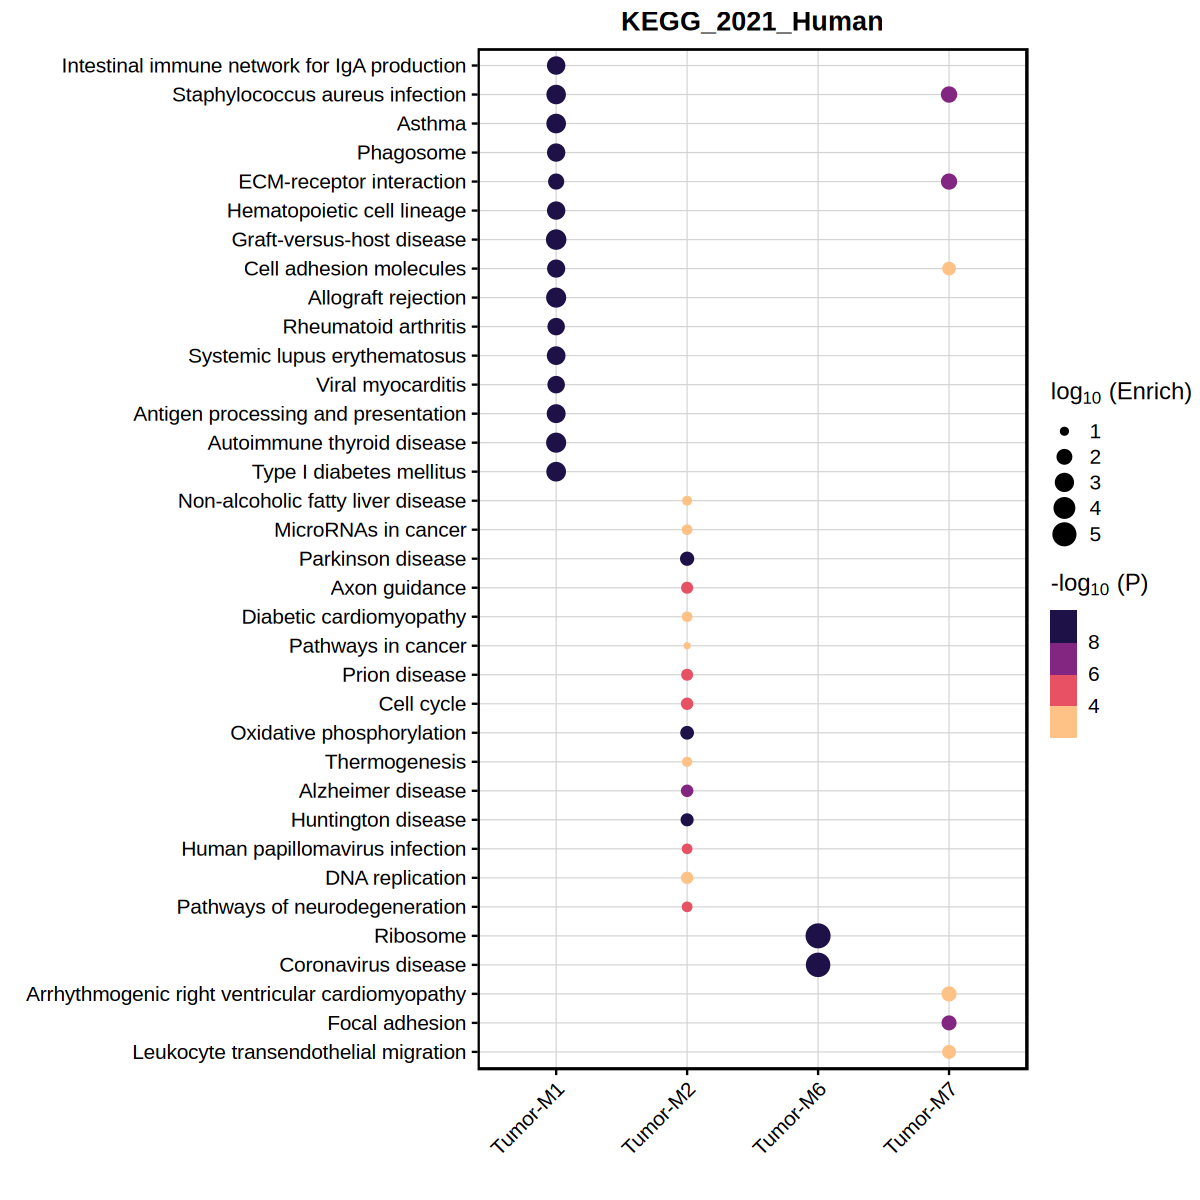

In [16]:
options(repr.plot.height = 10, repr.plot.width = 10)
#png(filename = "./results/kegg_enrichrPlot.png", width = 2800, height = 2000, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "KEGG_2021_Human", # this must match one of the dbs used previously
  n_terms=15, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

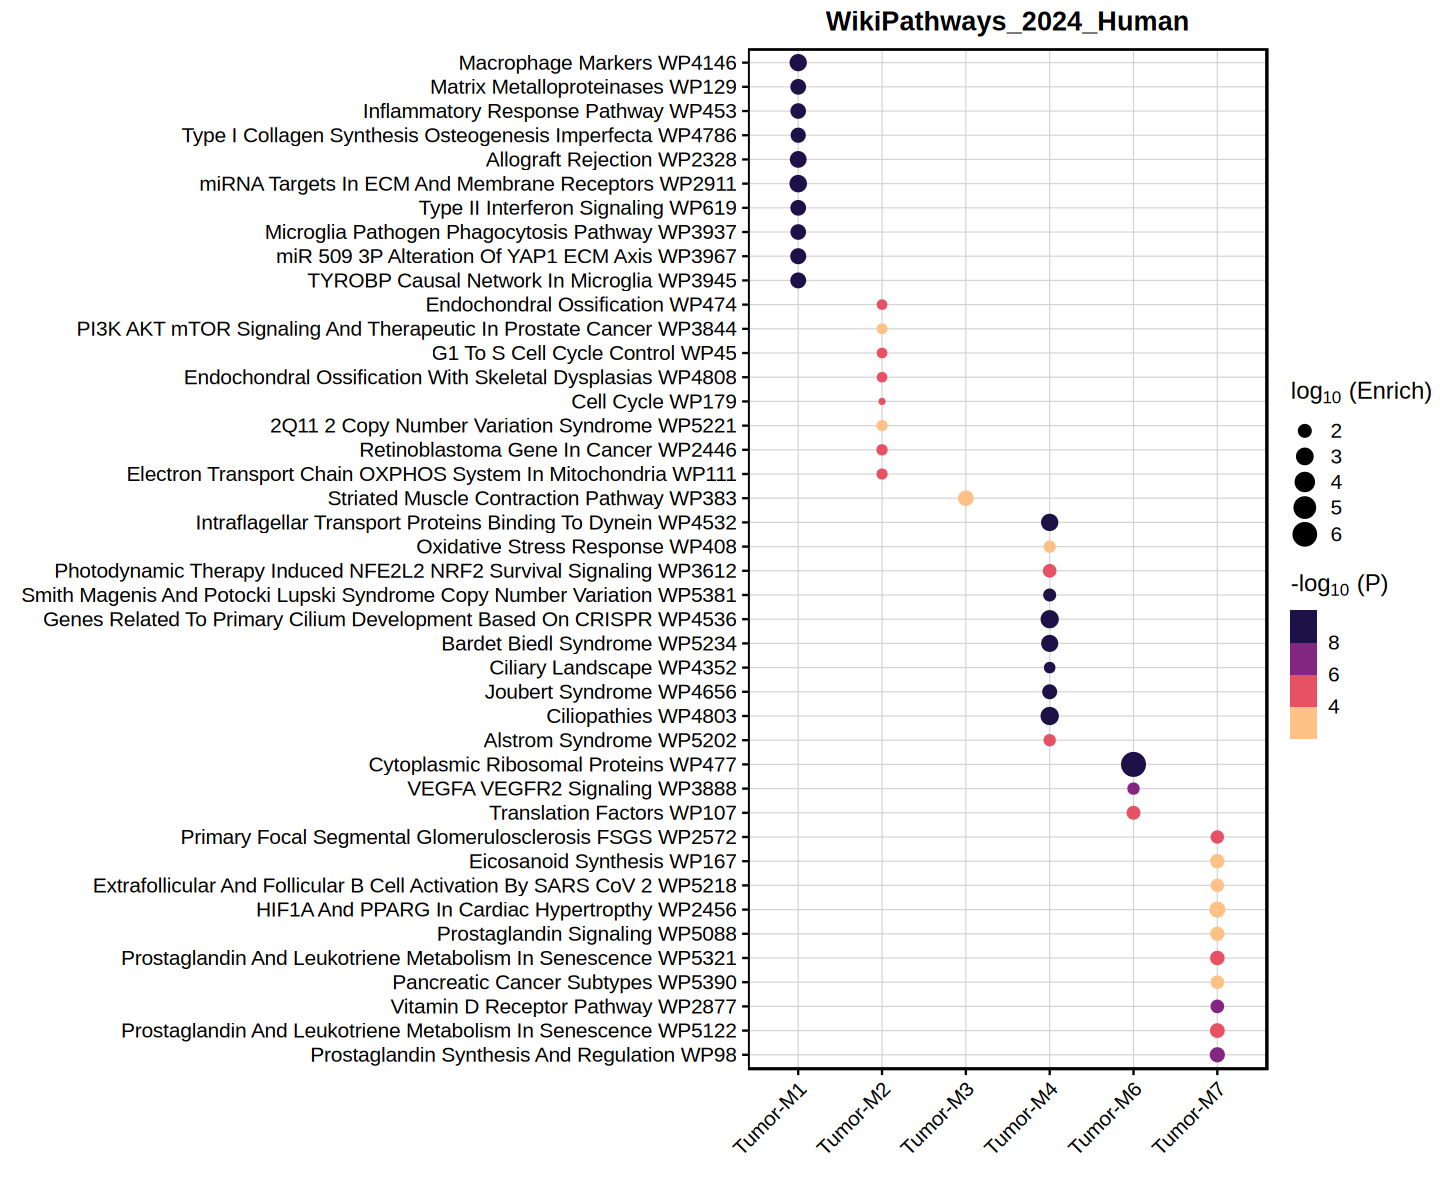

In [17]:
options(repr.plot.height = 10, repr.plot.width = 12)
#png(filename = "./results/wikipathway_enrichrPlot.png", width = 3800, height = 3000, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "WikiPathways_2024_Human", # this must match one of the dbs used previously
  n_terms=10, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

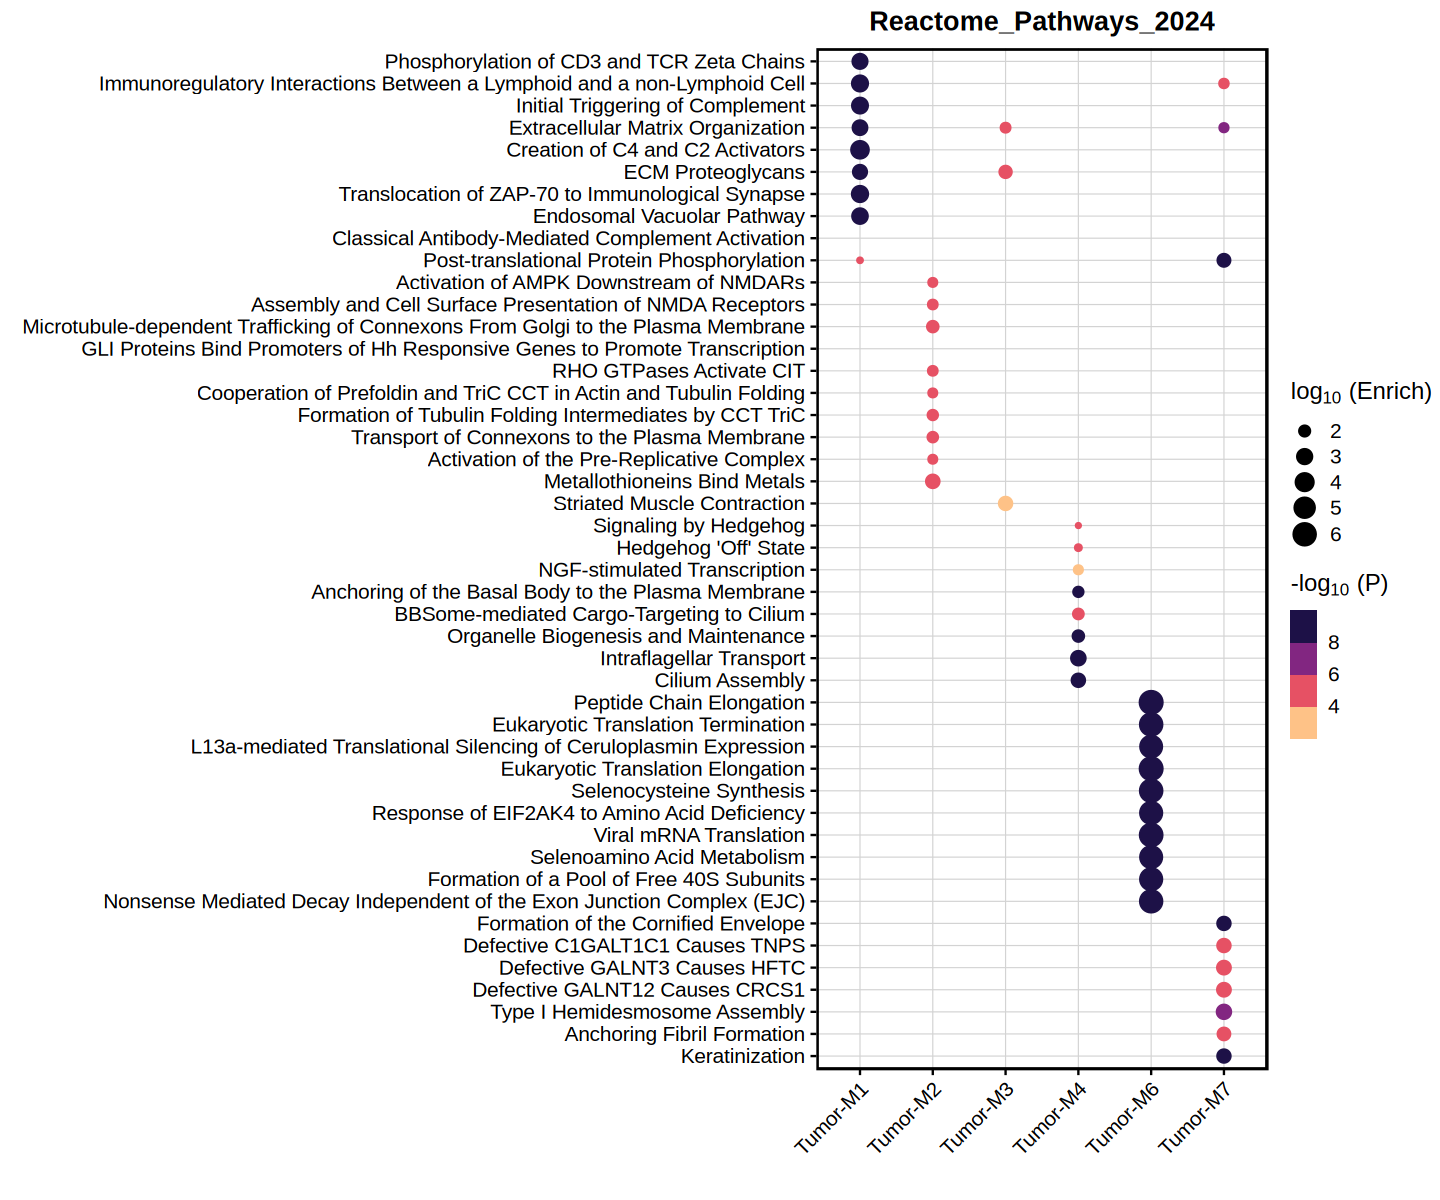

In [18]:
options(repr.plot.height = 10, repr.plot.width = 12)
#png(filename = "./results/reactome_enrichrPlot.png", width = 4500, height = 3200, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "Reactome_Pathways_2024", # this must match one of the dbs used previously
  n_terms=10, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

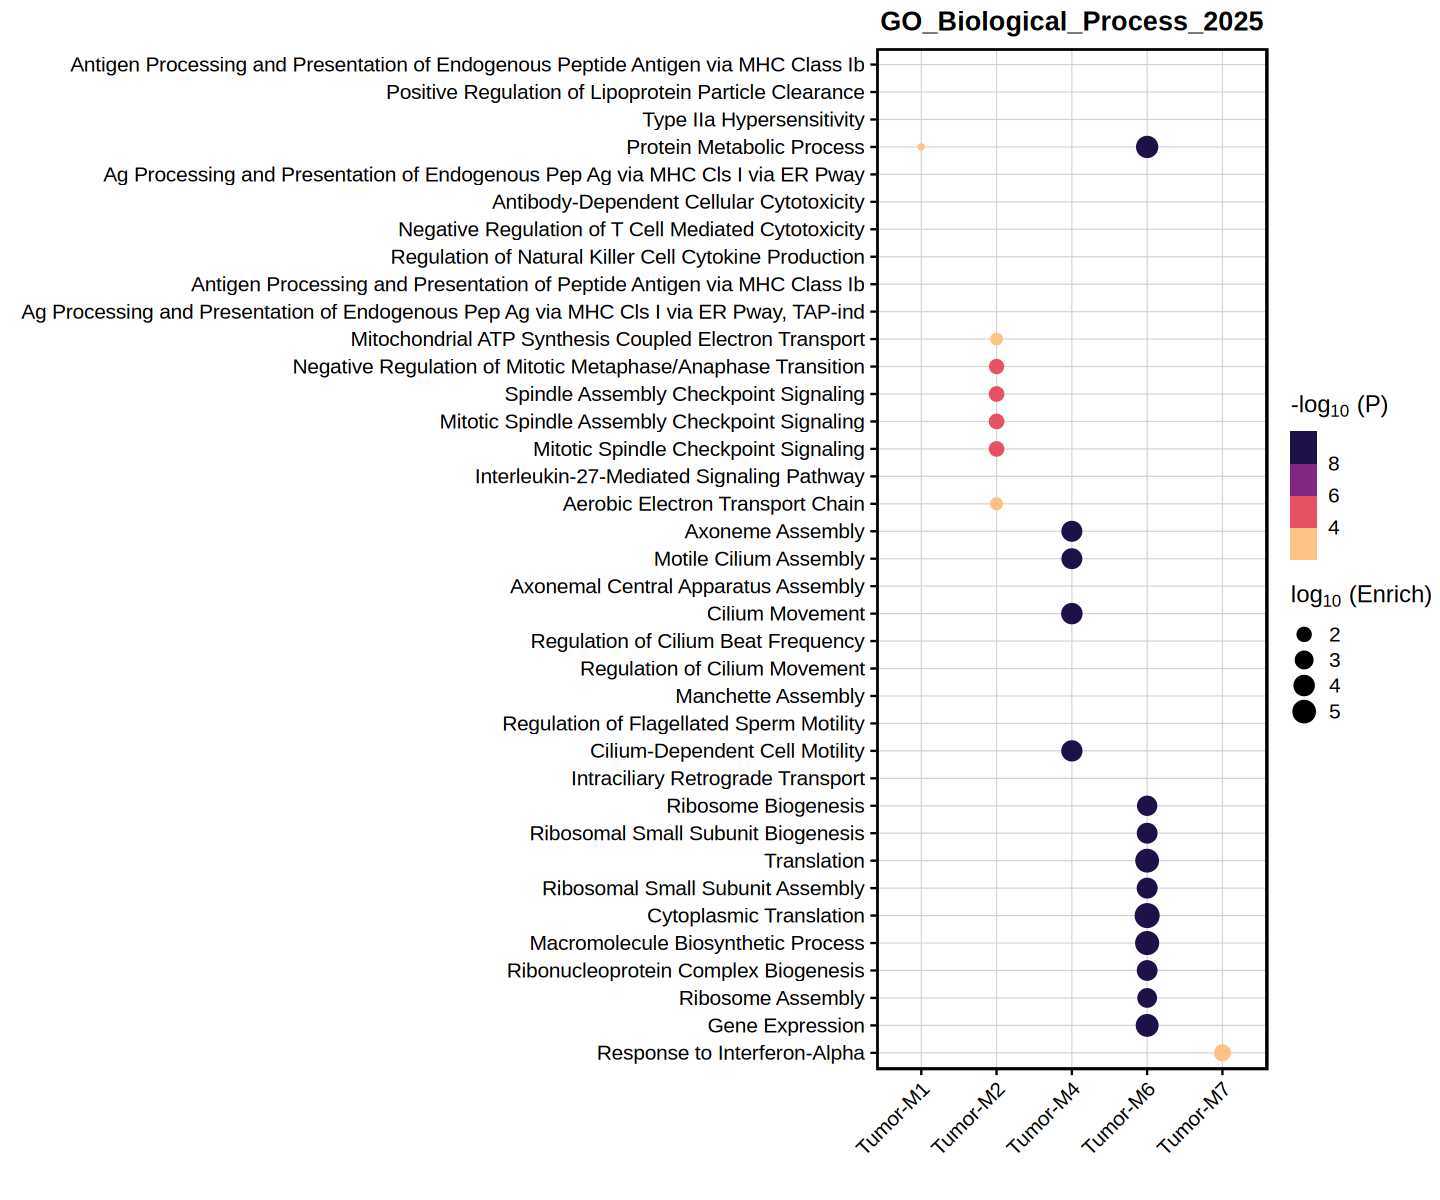

In [19]:
options(repr.plot.height = 10, repr.plot.width = 12)
#png(filename = "./results/GO_BP_enrichrPlot.png", width = 4400, height = 2800, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "GO_Biological_Process_2025", # this must match one of the dbs used previously
  n_terms=10, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

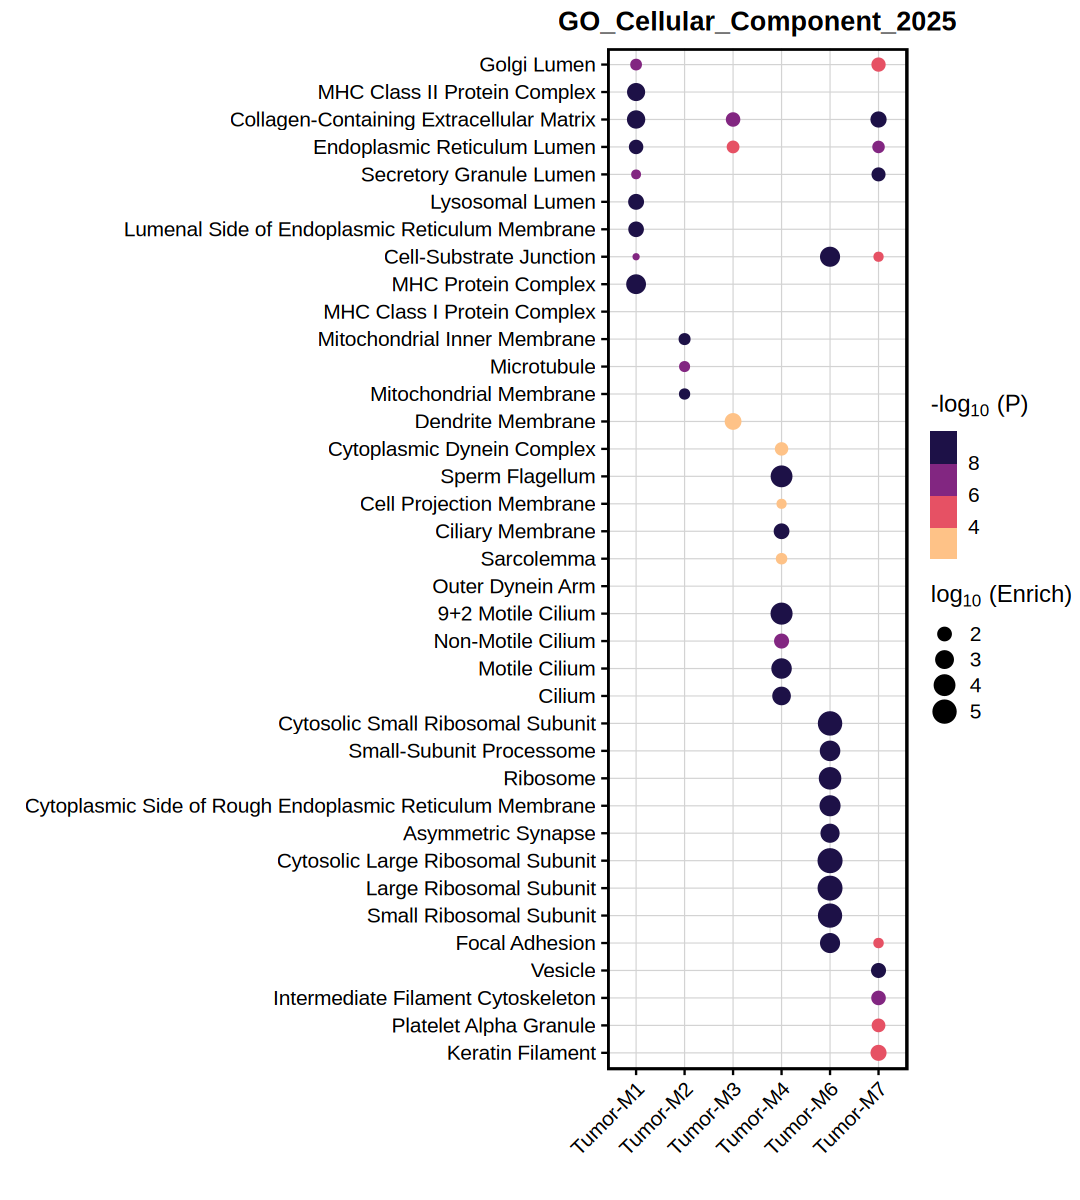

In [20]:
options(repr.plot.height = 10, repr.plot.width = 9)
#png(filename = "./results/GO_CC_enrichrPlot.png", width = 3800, height = 2800, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "GO_Cellular_Component_2025", # this must match one of the dbs used previously
  n_terms=10, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

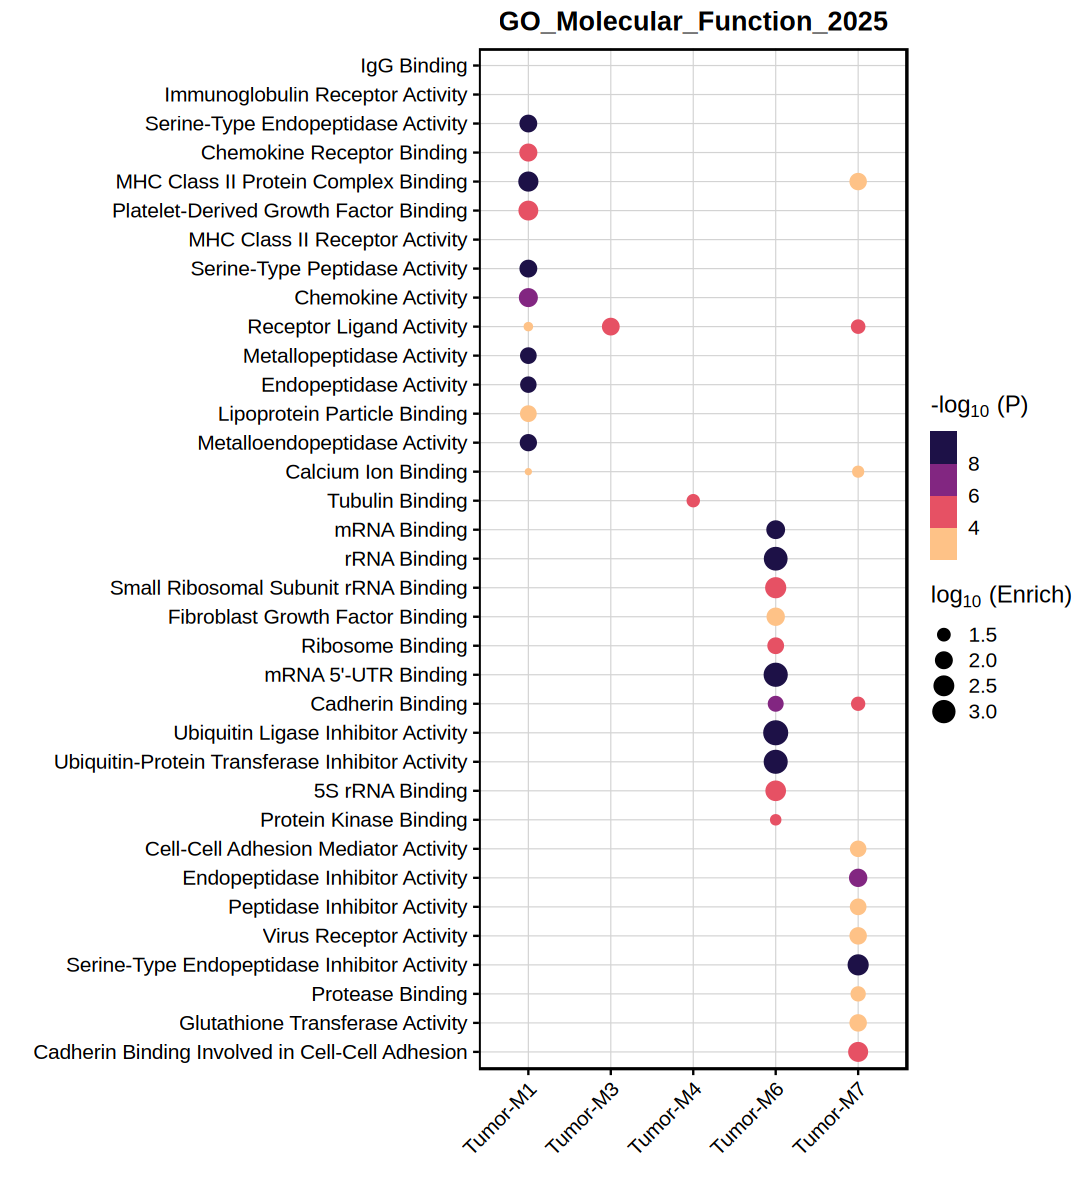

In [21]:
options(repr.plot.height = 10, repr.plot.width = 9)
#png(filename = "./results/GO_MF_enrichrPlot.png", width = 3200, height = 2400, res = 300)
# enrichr dotplot
EnrichrDotPlot(
  wgcna_obj,
  mods = "all", # use all modules (default)
  database = "GO_Molecular_Function_2025", # this must match one of the dbs used previously
  n_terms=15, # number of terms per module
  term_size=12, # font size for the terms
  p_adj = TRUE  # show the p-val or adjusted p-val?
)  + scale_color_stepsn(colors=rev(viridis::magma(256)))
#dev.off()

## Differential Module Eigengene Analysis

In [22]:
# compute module hub scores for projected modules:
wgcna_obj <- ModuleExprScore(
                  wgcna_obj,
                  n_genes = 'all',
                  method='Seurat'
                )

In [23]:
poor_grp <- wgcna_obj@meta.data %>% subset(cell_type == 'Tumour_cells' & chemotherapy_score == 1) %>% rownames
good_grp <- wgcna_obj@meta.data %>% subset(cell_type == 'Tumour_cells' & chemotherapy_score == 3) %>% rownames
print(length(poor_grp))
print(length(good_grp))

[1] 6994
[1] 1735


In [24]:
DMEs <- FindDMEs(
  wgcna_obj,
  barcodes1 = poor_grp,
  barcodes2 = good_grp,
  test.use='wilcox',
  wgcna_name='HGSOC',
    features = "ModuleScores"
)
print(dim(DMEs))
head(DMEs, 10)

[1] 7 6


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,module
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Tumor-M1,0.000000e+00,-4.3126799,0.380,0.986,0.000000e+00,Tumor-M1
Tumor-M6,0.000000e+00,0.7815632,1.000,1.000,0.000000e+00,Tumor-M6
Tumor-M5,7.722639e-227,-0.6153196,0.986,0.998,5.405847e-226,Tumor-M5
Tumor-M3,8.412948e-100,0.5719514,0.428,0.720,5.889063e-99,Tumor-M3
Tumor-M7,6.871079e-19,1.0001549,0.763,1.000,4.809755e-18,Tumor-M7
Tumor-M4,6.928962e-15,0.2746850,0.078,0.144,4.850273e-14,Tumor-M4
Tumor-M2,6.236496e-02,2.3146032,0.555,0.787,4.365547e-01,Tumor-M2


Loading required package: ggforestplot



[1] "Please be aware comparison group/groups are not provided, which may casue an ERROR. PlotDMEsLollipop function will automatically assume all values are within the same group."


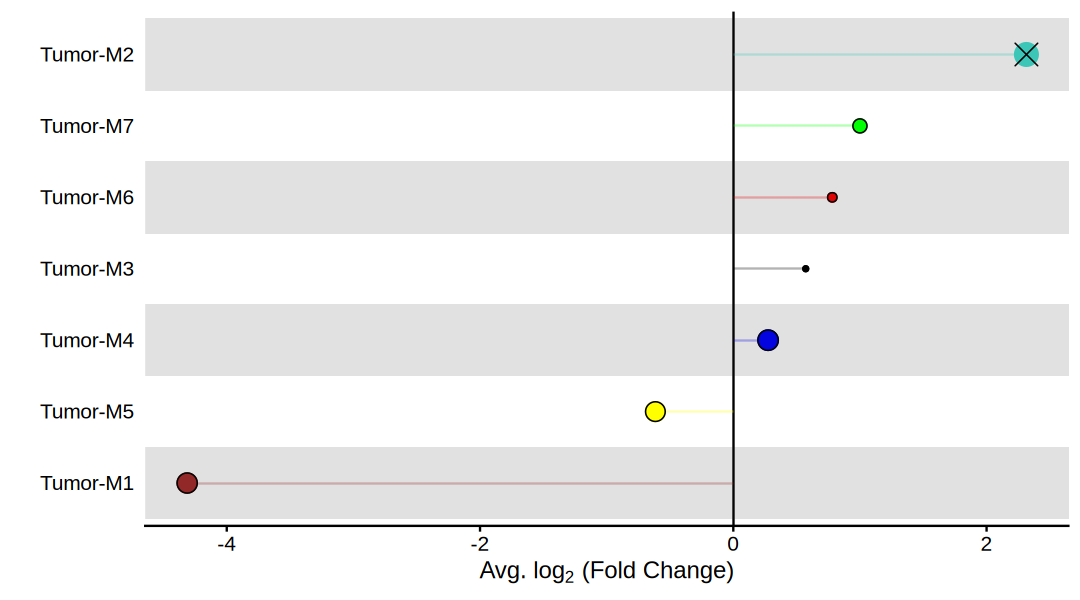

In [25]:
options(repr.plot.height = 5, repr.plot.width = 9)
PlotDMEsLollipop(
  wgcna_obj, 
  DMEs, 
  wgcna_name='HGSOC', 
  pvalue = "p_val_adj"
)

## Spatial Plot

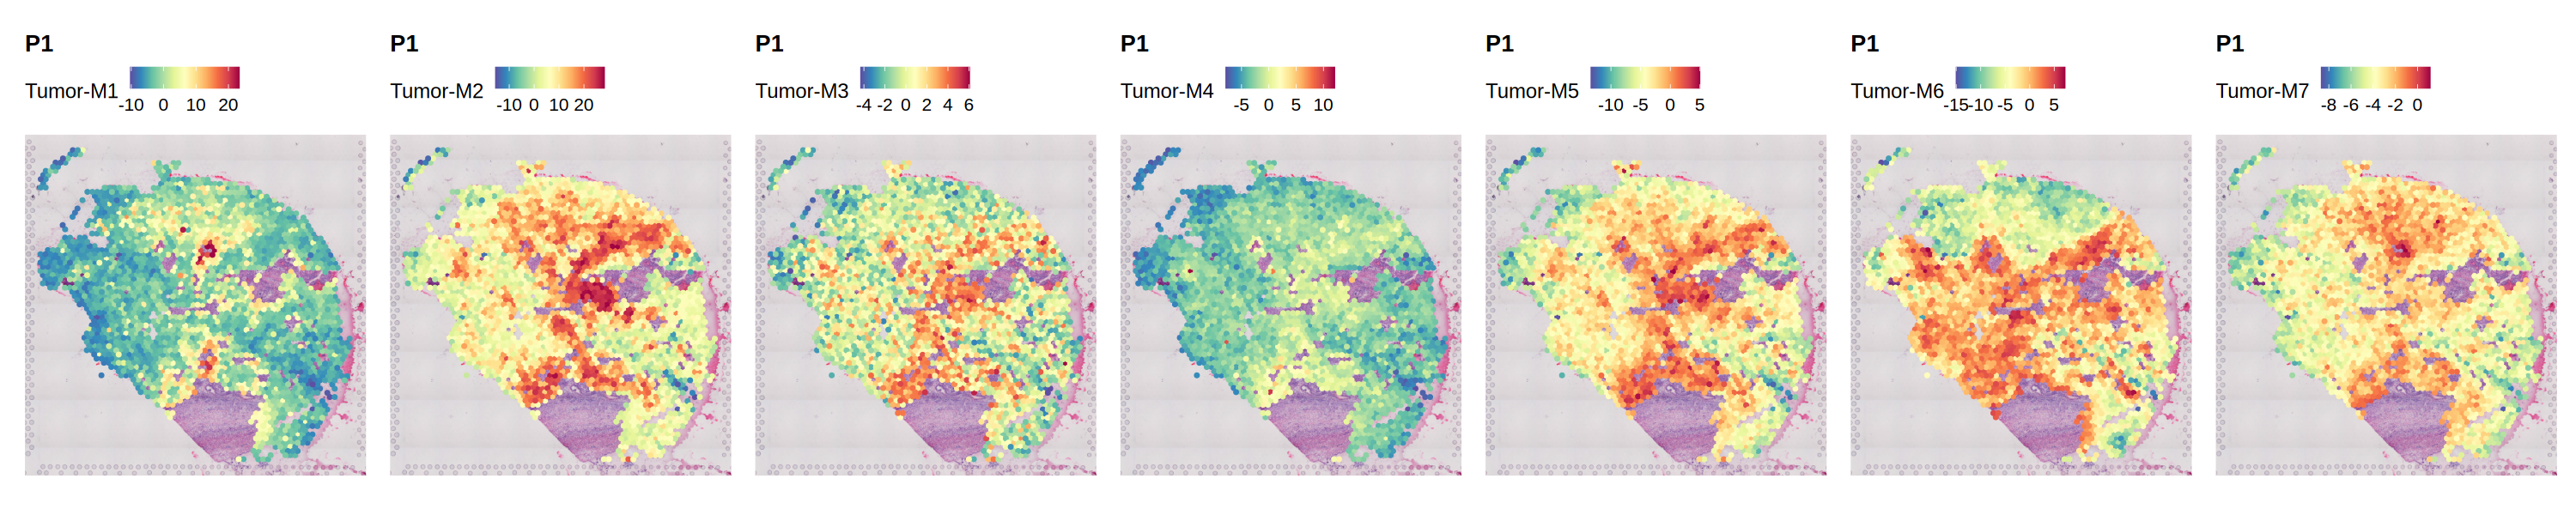

In [26]:
options(repr.plot.height = 5, repr.plot.width = 25)

#png(filename = "./results/spatial_plot/P1.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P1",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
) 

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P1")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot

# Combine and show plots
# dev.off()

In [27]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P2.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P2",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P2")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot

dev.off()

pdf 
  2

In [28]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P3.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P3",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P3")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot
dev.off()

pdf 
  2

In [29]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P4.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P4",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P4")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot
dev.off()

pdf 
  2

In [30]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P5.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P5",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P5")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot
dev.off()

pdf 
  2

In [31]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P6.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P6",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P6")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot
dev.off()

pdf 
  2

In [32]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P7.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P7",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P7")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot
dev.off()

pdf 
  2

In [33]:
options(repr.plot.height = 5, repr.plot.width = 25)

png(filename = "./results/spatial_plot/P8.png", width = 5000, height = 1000, res = 300)
plots_list <- SpatialFeaturePlot(
  wgcna_obj,
  features = c('Tumor-M1','Tumor-M2',  'Tumor-M3','Tumor-M4', 'Tumor-M5','Tumor-M6', 'Tumor-M7'),
    images = "P8",
    #image.scale = "hires",
    pt.size.factor = 2.5,
    ncol = 7
)

# Add y-axis label to each plot
plots_list <- lapply(plots_list, function(p) {
  p + labs(title = "P8")
})

# Combine plots using patchwork
final_plot <- wrap_plots(plots_list, ncol = 7)
final_plot
dev.off()

pdf 
  2